In [1]:
import duckdb
from pathlib import Path
import pandas as pd

In [2]:
# 02_cleaning_eda.ipynb — Cell A: inspect raw CSVs before schema design

PROJECT_ROOT = Path.cwd().parent
RAW = PROJECT_ROOT / "data" / "raw"

files = [
    "entsoe_generation_AT.csv",
    "entsoe_load_AT.csv",
    "entsoe_prices_AT.csv",
    "weather_vienna.csv",
]

for fname in files:
    path = RAW / fname
    if not path.exists():
        print(f"!! MISSING: {path}\n")
        continue
    size_kb = path.stat().st_size / 1024
    print("=" * 80)
    print(f"  {fname}   ({size_kb:,.0f} KB)")
    print("=" * 80)
    with open(path) as f:
        for i, line in enumerate(f):
            if i >= 5:
                break
            print(f"L{i}: {line.rstrip()[:160]}")
    print()

  entsoe_generation_AT.csv   (30,551 KB)
L0: ,Biomass,Biomass,Fossil Gas,Fossil Gas,Fossil Hard coal,Fossil Hard coal,Fossil Oil,Fossil Oil,Geothermal,Geothermal,Hydro Pumped Storage,Hydro Pumped Storage,H
L1: ,Actual Aggregated,Actual Consumption,Actual Aggregated,Actual Consumption,Actual Aggregated,Actual Consumption,Actual Aggregated,Actual Consumption,Actual Aggr
L2: 2019-01-01 01:00:00+01:00,304.0,0.0,1056.4,0.0,154.4,0.0,0.0,0.0,0.07,0.0,0.0,1583.6,2692.0,0.0,204.0,0.0,22.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,200.0,0.0
L3: 2019-01-01 01:15:00+01:00,304.0,0.0,1012.8,0.0,154.4,0.0,0.0,0.0,0.07,0.0,0.0,1605.6,2689.6,0.0,157.6,0.0,22.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,192.0,0.0
L4: 2019-01-01 01:30:00+01:00,304.0,0.0,937.6,0.0,155.6,0.0,0.0,0.0,0.07,0.0,0.0,1633.2,2712.4,0.0,133.2,0.0,22.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,184.0,0.0

  entsoe_load_AT.csv   (6,783 KB)
L0: ,Actual Load
L1: 2019-01-01 01:00:00+01:00,5975.6
L2: 2019-01-01 01:15:00+01:00,5889.6
L3: 2019-01-01 01:30:00+01:00,5837.2
L4

In [3]:
# 02_cleaning_eda.ipynb — Cell B: open DuckDB + create schema

PROJECT_ROOT = Path.cwd().parent
PROCESSED = PROJECT_ROOT / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)

DB_PATH = PROCESSED / "austria_energy.duckdb"
con = duckdb.connect(str(DB_PATH))

# Clean slate — drop everything for safe re-runs while iterating
for tbl in ["generation_15min", "demand_15min",
            "generation", "demand", "prices", "weather", "owid_energy_at"]:
    con.execute(f"DROP TABLE IF EXISTS {tbl}")

## This version is just for DuckDB/PostgreSQL dialect
## For example, for generation_15min, the following is the correct syntax:

## con.execute("""
## CREATE OR REPLACE TABLE generation_15min (
##     ts_utc      TIMESTAMPTZ NOT NULL,
##     fuel_type   VARCHAR     NOT NULL,
##     flow        VARCHAR     NOT NULL,
##     mw          DOUBLE,
##     PRIMARY KEY (ts_utc, fuel_type, flow)
## )
## """)

# ── Staging (15-min, long format) ────────────────────────────────────────
con.execute("""
CREATE TABLE generation_15min (
    ts_utc      TIMESTAMPTZ NOT NULL,
    fuel_type   VARCHAR     NOT NULL,
    flow        VARCHAR     NOT NULL,      -- 'generation' or 'consumption'
    mw          DOUBLE,
    PRIMARY KEY (ts_utc, fuel_type, flow)
)
""")

con.execute("""
CREATE TABLE demand_15min (
    ts_utc     TIMESTAMPTZ PRIMARY KEY,
    demand_mw  DOUBLE          -- allow NULL; we'll count gaps in QA
)
""")

# ── Final hourly tables (no resampling needed — native hourly) ──────────
con.execute("""
CREATE TABLE prices (
    ts_utc         TIMESTAMPTZ PRIMARY KEY,
    price_eur_mwh  DOUBLE       -- allow NULL; we'll count gaps in QA
)
""")

con.execute("""
CREATE TABLE weather (
    ts_utc          TIMESTAMPTZ PRIMARY KEY,
    temperature_c   DOUBLE,
    solar_wm2       DOUBLE,
    wind_kmh        DOUBLE,
    precip_mm       DOUBLE,
    cloudcover_pct  DOUBLE
)
""")

# generation, demand, owid_energy_at are created via CTAS in later cells.

print(con.sql("SHOW TABLES").df())

               name
0      demand_15min
1  generation_15min
2        load_15min
3            prices
4           weather


In [4]:
# 02_cleaning_eda.ipynb — Cell C: load OWID + prices + weather

RAW = PROJECT_ROOT / "data" / "raw"

# ── 1. OWID — annual, no TZ, CTAS straight from CSV ─────────────────────
con.execute(f"""
CREATE TABLE owid_energy_at AS
SELECT *
FROM read_csv_auto('{RAW / "owid_energy_AUT.csv"}', header=true)
""")
n = con.sql("SELECT COUNT(*) FROM owid_energy_at").fetchone()[0]  # pyright: ignore[reportOptionalSubscript]
print(f"owid_energy_at: {n} rows")

# ── 2. Prices — timestamps already carry offsets, parse to UTC ──────────
df_p = pd.read_csv(RAW / "entsoe_prices_AT.csv", index_col=0, parse_dates=True)
df_p.index = pd.to_datetime(df_p.index, utc=True)         # to UTC
df_p = df_p.rename_axis("ts_utc").reset_index()
df_p.columns = ["ts_utc", "price_eur_mwh"]
# there exists an explicit form of insert
# It is for assuring to be name sensitive about columns and not just order
con.execute("INSERT INTO prices SELECT * FROM df_p")
n = con.sql("SELECT COUNT(*) FROM prices").fetchone()[0]  # pyright: ignore[reportOptionalSubscript]
print(f"prices: {n} rows")

# ── 3. Weather — already UTC, just tag the index ────────────────────────
df_w = pd.read_csv(RAW / "weather_vienna.csv",
                   index_col="timestamp", parse_dates=True)
df_w.index = df_w.index.tz_localize("UTC")     # naive → UTC label, no shift  # pyright: ignore[reportAttributeAccessIssue]
df_w = df_w.rename(columns={
    "temperature_2m":      "temperature_c",
    "shortwave_radiation": "solar_wm2",
    "windspeed_10m":       "wind_kmh",
    "precipitation":       "precip_mm",
    "cloudcover":          "cloudcover_pct",
}).rename_axis("ts_utc").reset_index()
con.execute("INSERT INTO weather SELECT * FROM df_w")
n = con.sql("SELECT COUNT(*) FROM weather").fetchone()[0]  # pyright: ignore[reportOptionalSubscript]
print(f"weather: {n} rows")

owid_energy_at: 126 rows
prices: 52609 rows
weather: 52608 rows


In [5]:
# 02_cleaning_eda.ipynb — Cell D: sanity check what's in the DB - Part 1
con.sql("""
SELECT 'prices'  AS tbl, COUNT(*) AS rows,
       MIN(ts_utc) AS first_ts, MAX(ts_utc) AS last_ts
FROM prices
UNION ALL
SELECT 'weather', COUNT(*), MIN(ts_utc), MAX(ts_utc) FROM weather
UNION ALL
SELECT 'owid',    COUNT(*), NULL, NULL FROM owid_energy_at
""").df()

,tbl,rows,first_ts,last_ts
0,prices,52609,2019-01-01 01:00:00+01:00,2025-01-01 01:00:00+01:00
1,weather,52608,2019-01-01 01:00:00+01:00,2025-01-01 00:00:00+01:00
2,owid,126,NaT,NaT


In [6]:
# 02_cleaning_eda.ipynb — Cell D: sanity check what's in the DB - Part 2
con.sql("""
SELECT 'demand_15min' AS tbl,
       COUNT(*)                              AS rows,
       COUNT(*) FILTER (WHERE demand_mw IS NULL) AS nulls,
       ROUND(100.0 * COUNT(*) FILTER (WHERE demand_mw IS NULL) / COUNT(*), 3)
                                             AS pct_null
FROM demand_15min
UNION ALL
SELECT 'generation_15min',
       COUNT(*),
       COUNT(*) FILTER (WHERE mw IS NULL),
       ROUND(100.0 * COUNT(*) FILTER (WHERE mw IS NULL) / COUNT(*), 3)
FROM generation_15min
""").df()

,tbl,rows,nulls,pct_null
0,demand_15min,0,0,NaN
1,generation_15min,0,0,NaN


In [7]:
# 02_cleaning_eda.ipynb — Cell E: melt generation wide → long, load demand

# ── 4. Generation — wide MultiIndex CSV → long staging ─────────────────────
df_g = pd.read_csv(
    RAW / "entsoe_generation_AT.csv",
    header=[0, 1],          # 2-row header → MultiIndex columns
    index_col=0,
)
# Mixed offsets across DST → utc=True normalises both to UTC
df_g.index = pd.to_datetime(df_g.index, utc=True)
df_g.index.name = "ts_utc"

# Name the column levels so stack() produces nice column names
df_g.columns.names = ["fuel_type", "_flow_raw"]

# Wide → long: every (fuel_type, flow) column becomes its own row
df_g_long = (
    df_g
    .stack(level=["fuel_type", "_flow_raw"], future_stack=True)
    .rename("mw")  # pyright: ignore[reportArgumentType]
    .reset_index()
    .dropna(subset=["mw"])      # drop rows ENTSO-E didn't report
)

# Map ENTSO-E flow labels → our schema
flow_map = {
    "Actual Aggregated":  "generation",
    "Actual Consumption": "consumption",
}
df_g_long["flow"] = df_g_long["_flow_raw"].map(flow_map)

# Defensive: error if ENTSO-E ships a new flow label we haven't handled
unmapped = df_g_long["flow"].isna()
if unmapped.any():
    raise ValueError(
        f"Unknown ENTSO-E flow types: "
        f"{df_g_long.loc[unmapped, '_flow_raw'].unique().tolist()}"
    )

df_g_long = df_g_long[["ts_utc", "fuel_type", "flow", "mw"]]

con.execute("""
    INSERT INTO generation_15min (ts_utc, fuel_type, flow, mw)
    SELECT ts_utc, fuel_type, flow, mw FROM df_g_long
""")
n = con.sql("SELECT COUNT(*) FROM generation_15min").fetchone()[0]  # pyright: ignore[reportOptionalSubscript]
print(f"generation_15min: {n:,} rows")


# ── 5. Demand — single-column CSV, straight-through ────────────────────────
df_d = pd.read_csv(
    RAW / "entsoe_load_AT.csv",
    index_col=0,
)
df_d.index = pd.to_datetime(df_d.index, utc=True)
df_d = df_d.rename_axis("ts_utc").reset_index()
df_d.columns = ["ts_utc", "demand_mw"]

con.execute("""
    INSERT INTO demand_15min (ts_utc, demand_mw)
    SELECT ts_utc, demand_mw FROM df_d
""")
n = con.sql("SELECT COUNT(*) FROM demand_15min").fetchone()[0]  # pyright: ignore[reportOptionalSubscript]
print(f"demand_15min: {n:,} rows")

generation_15min: 5,471,232 rows
demand_15min: 210,432 rows


In [8]:
# 02_cleaning_eda.ipynb — Cell F: re-run QA on the populated tables
con.sql("""
SELECT 'generation_15min' AS tbl,
       COUNT(*)                                  AS rows,
       COUNT(DISTINCT fuel_type)                 AS n_fuels,
       COUNT(*) FILTER (WHERE mw IS NULL)        AS nulls,
       MIN(ts_utc) AS first_ts, MAX(ts_utc) AS last_ts
FROM generation_15min
UNION ALL
SELECT 'demand_15min', COUNT(*), NULL,
       COUNT(*) FILTER (WHERE demand_mw IS NULL),
       MIN(ts_utc), MAX(ts_utc)
FROM demand_15min
""").df()

,tbl,rows,n_fuels,nulls,first_ts,last_ts
0,generation_15min,5471232,13,0,2019-01-01 01:00:00+01:00,2025-01-01 00:45:00+01:00
1,demand_15min,210432,<NA>,0,2019-01-01 01:00:00+01:00,2025-01-01 00:45:00+01:00


In [9]:
# 02_cleaning_eda.ipynb — Cell G: resample 15-min → hourly via SQL

# ── 6. Generation hourly: filter junk consumption rows + aggregate ─────────
con.execute("""
CREATE OR REPLACE TABLE generation AS
SELECT
    time_bucket(INTERVAL 1 HOUR, ts_utc) AS ts_utc,
    fuel_type,
    flow,
    AVG(mw)   AS mw,            -- MW is instantaneous power → average, don't sum
    COUNT(*)  AS n_quarters     -- expect 4 per row; <4 means source gap
FROM generation_15min
WHERE flow = 'generation'                                       -- always keep
   OR (flow = 'consumption' AND fuel_type = 'Hydro Pumped Storage')
                                                                -- only pumped storage actually consumes
GROUP BY 1, 2, 3
ORDER BY 1, 2, 3
""")
n_g = con.sql("SELECT COUNT(*) FROM generation").fetchone()[0]  # pyright: ignore[reportOptionalSubscript]
print(f"generation: {n_g:,} rows")

# ── 7. Demand hourly ────────────────────────────────────────────────────────
con.execute("""
CREATE OR REPLACE TABLE demand AS
SELECT
    time_bucket(INTERVAL 1 HOUR, ts_utc) AS ts_utc,
    AVG(demand_mw)  AS demand_mw,
    COUNT(*)        AS n_quarters
FROM demand_15min
GROUP BY 1
ORDER BY 1
""")
n_d = con.sql("SELECT COUNT(*) FROM demand").fetchone()[0]  # pyright: ignore[reportOptionalSubscript]
print(f"demand: {n_d:,} rows")

generation: 736,512 rows
demand: 52,608 rows


In [10]:
# Quarter-count check: should always be 4
display(con.sql("""
SELECT 'generation' AS tbl, n_quarters, COUNT(*) AS n_rows
FROM generation
GROUP BY n_quarters
UNION ALL
SELECT 'demand', n_quarters, COUNT(*)
FROM demand
GROUP BY n_quarters
ORDER BY tbl, n_quarters
""").df())

# What's actually in Austria's generation mix?
display(con.sql("""
SELECT
    fuel_type,
    flow,
    ROUND(AVG(mw))      AS avg_mw,
    ROUND(MAX(mw))      AS peak_mw,
    ROUND(SUM(mw) / 1e6, 2) AS total_twh   -- MW × hours / 1e6 = TWh
FROM generation
GROUP BY fuel_type, flow
ORDER BY avg_mw DESC NULLS LAST
""").df())

,tbl,n_quarters,n_rows
0,demand,4,52608
1,generation,4,736512


,fuel_type,flow,avg_mw,peak_mw,total_twh
0,Hydro Run-of-river and poundage,generation,3224.0,6224.0,169.60
1,Fossil Gas,generation,976.0,3926.0,51.37
2,Wind Onshore,generation,893.0,3498.0,46.97
3,Hydro Pumped Storage,generation,595.0,3185.0,31.28
4,Hydro Water Reservoir,generation,518.0,1754.0,27.23
5,Hydro Pumped Storage,consumption,298.0,2197.0,15.70
6,Solar,generation,219.0,4157.0,11.50
7,Biomass,generation,212.0,336.0,11.17
8,Waste,generation,100.0,100.0,5.26
9,Fossil Hard coal,generation,30.0,492.0,1.58


In [11]:
con.sql("""
SELECT fuel_type,
       COUNT(DISTINCT mw)         AS n_unique_values,
       ROUND(STDDEV(mw), 4)       AS std_mw,
       ROUND(MIN(mw), 2)          AS min_mw,
       ROUND(MAX(mw), 2)          AS max_mw
FROM generation
WHERE flow = 'generation'
GROUP BY fuel_type
ORDER BY n_unique_values
""").df()

,fuel_type,n_unique_values,std_mw,min_mw,max_mw
0,Other,1,0.0000,22.00,22.00
1,Fossil Oil,1,0.0000,0.00,0.00
2,Other renewable,1,0.0000,0.00,0.00
3,Geothermal,1,0.0000,0.07,0.07
4,Waste,1,0.0000,100.00,100.00
5,Biomass,277,61.0503,52.00,336.00
6,Fossil Hard coal,2468,78.2620,0.00,492.40
7,Solar,2673,503.0924,0.00,4157.00
8,Wind Onshore,3322,835.9869,4.00,3498.00
9,Hydro Water Reservoir,19990,334.1808,6.40,1753.60


## Phase 2 complete

DuckDB file: `data/processed/austria_energy.duckdb`

| Table | Grain | Source |
|---|---|---|
| `generation`        | hourly × (fuel_type, flow) | ENTSO-E (resampled from 15-min) |
| `demand`            | hourly                     | ENTSO-E (resampled from 15-min) |
| `prices`            | hourly                     | ENTSO-E day-ahead              |
| `weather`           | hourly                     | Open-Meteo / ERA5 (Vienna)     |
| `owid_energy_at`    | annual                     | Our World in Data              |

All timestamps stored as UTC TIMESTAMPTZ. Staging tables (`generation_15min`,
`demand_15min`) retained for reproducibility. Resampling: `AVG(mw)` over
`time_bucket(INTERVAL 1 HOUR, ts_utc)`.

Notable: hydro dominates Austria's mix; coal phased out April 2020;
solar peak-to-avg ratio ~19× drives the duck curve dynamics.

In [16]:
# 02_cleaning_eda.ipynb — Cell H (Phase 3): missingness done right

# Continuity: in a time series, a missing hour is an ABSENT ROW, not a null.
# expected_hours = span in hours + 1 (inclusive). If actual == expected and
# there are no gaps, the index is continuous.
# NOTE: f-string SQL here is fine because table/column names are hardcoded
# constants — never do this with user-supplied input (SQL injection).
def continuity_check(con, table: str, value_col: str) -> pd.DataFrame:
    return con.sql(f"""
        SELECT
            '{table}'                                          AS tbl,
            COUNT(*)                                           AS rows,
            date_diff('hour', MIN(ts_utc), MAX(ts_utc)) + 1    AS expected_hours,
            date_diff('hour', MIN(ts_utc), MAX(ts_utc)) + 1
                - COUNT(*)                                     AS missing_hours,
            COUNT(*) FILTER (WHERE {value_col} IS NULL)        AS null_values
        FROM {table}
    """).df()

checks = [("demand", "demand_mw"), ("prices", "price_eur_mwh")]
display(pd.concat([continuity_check(con, t, c) for t, c in checks],
                  ignore_index=True))

# Weather has 5 value columns — scan each
display(con.sql("""
SELECT
    COUNT(*)                                         AS rows,
    date_diff('hour', MIN(ts_utc), MAX(ts_utc)) + 1  AS expected_hours,
    COUNT(*) FILTER (WHERE temperature_c  IS NULL)   AS null_temp,
    COUNT(*) FILTER (WHERE solar_wm2      IS NULL)   AS null_solar,
    COUNT(*) FILTER (WHERE wind_kmh       IS NULL)   AS null_wind,
    COUNT(*) FILTER (WHERE precip_mm      IS NULL)   AS null_precip,
    COUNT(*) FILTER (WHERE cloudcover_pct IS NULL)   AS null_cloud
FROM weather
""").df())

,tbl,rows,expected_hours,missing_hours,null_values
0,demand,52608,52608,0,0
1,prices,52609,52609,0,0


,rows,expected_hours,null_temp,null_solar,null_wind,null_precip,null_cloud
0,52608,52608,0,0,0,0,0


In [17]:
# Cell H (cont.): explicitly locate any gap using a window function.
# LAG pulls the previous row's timestamp; any step ≠ 1 hour is a gap.
# (This is your first window function — the OVER(ORDER BY) pattern is the
#  backbone of Phase 4's duck-curve and merit-order analyses.)
con.sql("""
WITH stepped AS (
    SELECT
        ts_utc,
        ts_utc - LAG(ts_utc) OVER (ORDER BY ts_utc) AS step
    FROM demand
)
SELECT ts_utc AS gap_after, step
FROM stepped
WHERE step <> INTERVAL 1 HOUR     -- first row's step is NULL, auto-excluded
ORDER BY ts_utc
""").df()   # expect 0 rows

,gap_after,step


Continuity verified in UTC, no imputation needed

In [18]:
# 02_cleaning_eda.ipynb — Cell I (Phase 3): summary stats BEFORE any plot
# median + p01/p99 are robust to the 2022 price spike in a way mean/std aren't.
# pct_zero is the zero-inflation flag (watch solar & precip light up).
con.sql("""
WITH series AS (
    SELECT 'demand_mw'  AS metric, demand_mw     AS v FROM demand
    UNION ALL SELECT 'price_eur_mwh', price_eur_mwh FROM prices
    UNION ALL SELECT 'temp_c',        temperature_c  FROM weather
    UNION ALL SELECT 'solar_wm2',     solar_wm2      FROM weather
    UNION ALL SELECT 'wind_kmh',      wind_kmh       FROM weather
    UNION ALL SELECT 'precip_mm',     precip_mm      FROM weather
    UNION ALL SELECT 'cloud_pct',     cloudcover_pct FROM weather
)
SELECT
    metric,
    ROUND(AVG(v), 1)                       AS mean,
    ROUND(median(v), 1)                    AS p50,
    ROUND(stddev(v), 1)                    AS std,
    ROUND(MIN(v), 1)                       AS min,
    ROUND(quantile_cont(v, 0.99), 1)       AS p99,
    ROUND(MAX(v), 1)                       AS max,
    ROUND(skewness(v), 2)                  AS skew,
    ROUND(100.0 * COUNT(*) FILTER (WHERE v = 0) / COUNT(*), 1) AS pct_zero
FROM series
GROUP BY metric
ORDER BY metric
""").df()

,metric,mean,p50,std,min,p99,max,skew,pct_zero
0,cloud_pct,61.4,80.0,40.3,0.0,100.0,100.0,-0.44,11.1
1,demand_mw,6949.6,6897.2,1333.1,4013.5,9907.3,10779.0,0.22,0.0
2,precip_mm,0.1,0.0,0.4,0.0,1.6,14.0,11.36,85.9
3,price_eur_mwh,104.1,71.8,103.6,-500.0,512.4,919.6,2.40,0.2
4,solar_wm2,147.7,7.0,221.4,0.0,810.0,905.0,1.49,47.0
5,temp_c,11.8,11.3,8.5,-9.6,30.6,36.3,0.21,0.1
6,wind_kmh,13.8,12.3,7.8,0.0,35.3,51.9,0.76,0.0


In [19]:
# Cell I (cont.): generation per fuel — the 8 REAL fuels only.
# Excludes the 5 nominal/placeholder fuels (constant or zero output).
# peak_to_avg surfaces solar's ~19× ratio → this is the RQ3 duck-curve hook.
con.sql("""
SELECT
    fuel_type,
    ROUND(AVG(mw))                              AS mean_mw,
    ROUND(median(mw))                           AS p50_mw,
    ROUND(MIN(mw))                              AS min_mw,
    ROUND(MAX(mw))                              AS max_mw,
    ROUND(100.0 * COUNT(*) FILTER (WHERE mw = 0) / COUNT(*), 1) AS pct_zero,
    ROUND(MAX(mw) / NULLIF(AVG(mw), 0), 1)      AS peak_to_avg
FROM generation
WHERE flow = 'generation'
  AND fuel_type NOT IN ('Waste','Other','Geothermal','Fossil Oil','Other renewable')
GROUP BY fuel_type
ORDER BY mean_mw DESC
""").df()

,fuel_type,mean_mw,p50_mw,min_mw,max_mw,pct_zero,peak_to_avg
0,Hydro Run-of-river and poundage,3224.0,3145.0,1337.0,6224.0,0.0,1.9
1,Fossil Gas,976.0,779.0,0.0,3926.0,7.7,4.0
2,Wind Onshore,893.0,612.0,4.0,3498.0,0.0,3.9
3,Hydro Pumped Storage,595.0,226.0,0.0,3185.0,35.7,5.4
4,Hydro Water Reservoir,518.0,452.0,6.0,1754.0,0.0,3.4
5,Solar,219.0,13.0,0.0,4157.0,44.6,19.0
6,Biomass,212.0,204.0,52.0,336.0,0.0,1.6
7,Fossil Hard coal,30.0,0.0,0.0,492.0,84.8,16.4


In [20]:
# Floor integrity check. A hard floor means: min == floor, a pile-up AT the
# floor, and ZERO observations below it.
# Note: comparing a DOUBLE with a tolerance (<= -499.99) instead of `= -500.0`
# is the safe habit — float equality is fragile in general, even though -500
# happens to be exactly representable here.
con.sql("""
SELECT
    MIN(price_eur_mwh)                                AS min_price,
    COUNT(*) FILTER (WHERE price_eur_mwh <= -499.99)  AS at_floor,
    COUNT(*) FILTER (WHERE price_eur_mwh <  -500.01)  AS below_floor,   -- expect 0
    COUNT(*) FILTER (WHERE price_eur_mwh <  0)         AS negative_hours
FROM prices
""").df()

,min_price,at_floor,below_floor,negative_hours
0,-500.0,1,0,650


In [21]:
# Floor hours in Vienna local time — they should cluster in sunny/windy,
# low-demand hours (spring/summer weekend middays). That's the merit-order
# floor: renewable oversupply with nowhere to go.
con.sql("""
SELECT
    ts_utc AT TIME ZONE 'Europe/Vienna'  AS ts_local,
    price_eur_mwh
FROM prices
WHERE price_eur_mwh <= -499.99
ORDER BY ts_local
""").df()

,ts_local,price_eur_mwh
0,2023-07-02 14:00:00,-500.0


In [22]:
# When do negative prices happen? If it's the merit-order effect, they cluster
# at midday (solar oversupply). Hour-of-day computed in Vienna LOCAL time —
# this is the seasonal-aggregation pattern we'll lean on throughout Phase 3/4.
con.sql("""
SELECT
    EXTRACT(hour FROM ts_utc AT TIME ZONE 'Europe/Vienna')  AS hour_local,
    COUNT(*) FILTER (WHERE price_eur_mwh < 0)                AS negative_hours,
    ROUND(AVG(price_eur_mwh), 1)                             AS avg_price
FROM prices
GROUP BY hour_local
ORDER BY hour_local
""").df()

,hour_local,negative_hours,avg_price
0,0,5,92.9
1,1,10,86.3
2,2,13,83.3
3,3,23,80.2
4,4,27,81.2
5,5,18,88.9
6,6,16,105.9
7,7,11,119.5
8,8,13,121.6
9,9,20,113.1


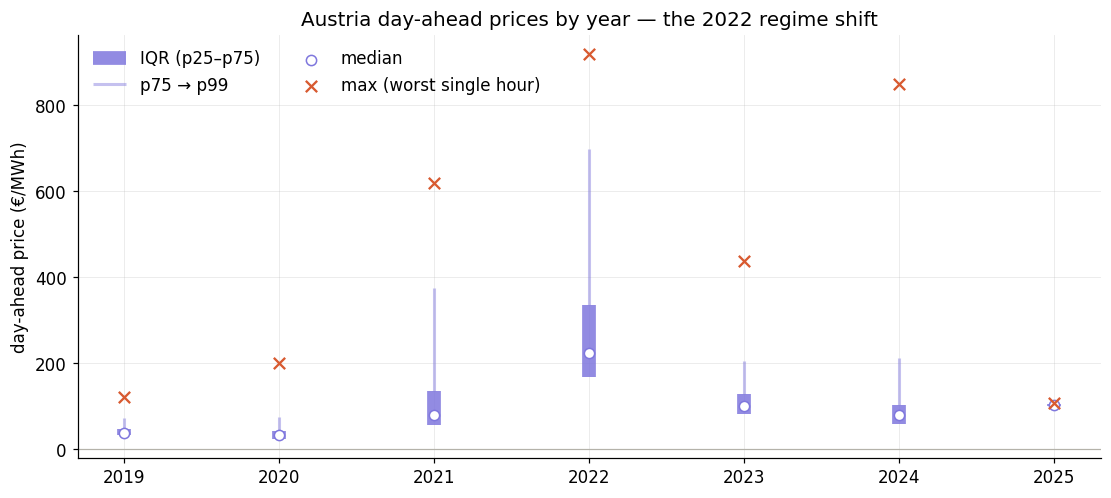

,yr,p25,p50,p75,p99,max,pct_neg
0,2019,32.9,39.2,48.0,72.7,121.5,0.8
1,2020,24.1,33.1,42.2,75.3,200.0,1.3
2,2021,56.9,79.0,137.0,375.4,620.0,0.7
3,2022,169.1,224.0,337.0,697.9,919.6,0.0
4,2023,82.1,101.9,128.8,206.3,437.5,1.3
5,2024,59.8,80.5,103.0,212.4,850.0,3.4
6,2025,100.0,103.0,106.0,108.9,109.0,0.0


In [ ]:
# 02_cleaning_eda.ipynb — Cell J (Phase 3): the ONE distribution worth plotting
# Of 13 metrics, only prices show a regime shift a summary number can't convey.
import sys
from pathlib import Path

import matplotlib.pyplot as plt

# make src/ importable from the notebook
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.viz import set_house_style, PALETTE  # noqa: E402

set_house_style()

# Per-year price structure — robust quantiles computed in SQL.
# Year extracted in UTC; the CET offset is immaterial at annual grain.
yr = con.sql("""
SELECT
    EXTRACT(year FROM ts_utc)                          AS yr,
    quantile_cont(price_eur_mwh, 0.25)                 AS p25,
    median(price_eur_mwh)                              AS p50,
    quantile_cont(price_eur_mwh, 0.75)                 AS p75,
    quantile_cont(price_eur_mwh, 0.99)                 AS p99,
    MAX(price_eur_mwh)                                 AS max,
    100.0 * COUNT(*) FILTER (WHERE price_eur_mwh < 0)
          / COUNT(*)                                   AS pct_neg
FROM prices
GROUP BY yr
ORDER BY yr
""").df()

fig, ax = plt.subplots()
x = yr["yr"]

ax.vlines(x, yr["p25"], yr["p75"], color=PALETTE["price"], lw=9, alpha=0.85,
          label="IQR (p25–p75)")
ax.vlines(x, yr["p75"], yr["p99"], color=PALETTE["price"], lw=2, alpha=0.45,
          label="p75 → p99")
ax.scatter(x, yr["p50"], facecolor="white", edgecolor=PALETTE["price"],
           s=45, zorder=5, label="median")
ax.scatter(x, yr["max"], marker="x", color=PALETTE["accent"], s=55, zorder=5,
           label="max (worst single hour)")

ax.axhline(0, color=PALETTE["muted"], lw=0.8)   # negative prices live below this
ax.set_ylabel("day-ahead price (€/MWh)")
ax.set_title("Austria day-ahead prices by year — the 2022 regime shift")
ax.legend(loc="upper left", ncol=2)
plt.show()

display(yr.round(1))

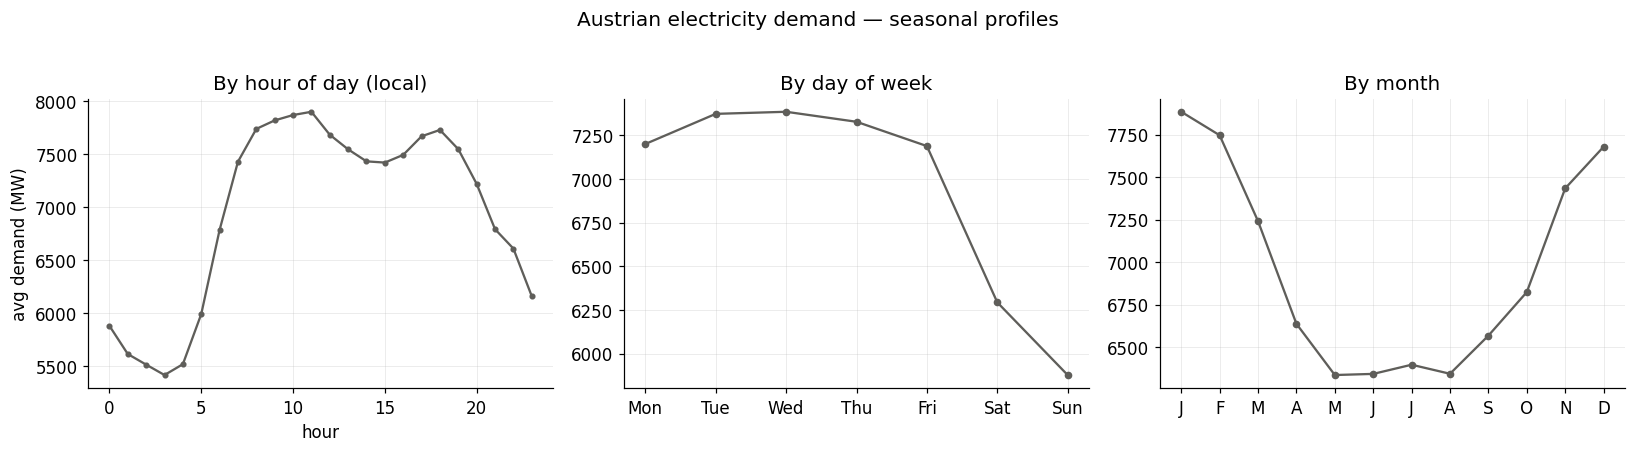

In [31]:
# 02_cleaning_eda.ipynb — Cell K (Phase 3): demand seasonality at three grains
# Same recipe each time: convert to Vienna local → EXTRACT a time part → average.
# Local time is non-negotiable here: a diurnal profile on raw UTC is shifted 1–2h.

set_house_style()

def demand_profile(part: str):
    # `part` is a trusted constant (hour/isodow/month) → f-string is safe.
    return con.sql(f"""
        SELECT EXTRACT({part} FROM ts_utc AT TIME ZONE 'Europe/Vienna') AS x,
               AVG(demand_mw) AS avg_demand
        FROM demand
        GROUP BY x ORDER BY x
    """).df()

hour  = demand_profile("hour")
week  = demand_profile("isodow")    # 1 = Mon … 7 = Sun
month = demand_profile("month")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(hour["x"], hour["avg_demand"], color=PALETTE["demand"], marker="o", ms=3)
ax[0].set(title="By hour of day (local)", xlabel="hour", ylabel="avg demand (MW)")

ax[1].plot(week["x"], week["avg_demand"], color=PALETTE["demand"], marker="o", ms=4)
ax[1].set(title="By day of week")
ax[1].set_xticks(range(1, 8)); ax[1].set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])

ax[2].plot(month["x"], month["avg_demand"], color=PALETTE["demand"], marker="o", ms=4)
ax[2].set(title="By month")
ax[2].set_xticks(range(1, 13)); ax[2].set_xticklabels(list("JFMAMJJASOND"))

fig.suptitle("Austrian electricity demand — seasonal profiles", y=1.02)
plt.tight_layout()
plt.show()